In [1]:
import pandas as pd
import numpy as np
df = pd.read_excel('525701-XLS-ENG.xlsx', sheet_name='amperity_dataset')
df.head()


,userid,age,gender,purchase_number,revenue,brand-type,id_adulterated
0,0,32,0,0,195.094274,1,1
1,0,32,0,1,174.436024,0,2
2,0,32,0,2,181.826480,0,2
3,1,28,1,0,408.938096,0,3
4,1,28,1,1,415.083744,0,3


# 1. How many unique customers does the firm actually have vs. how many customers do we count without identity resolution?

In [2]:
actual_unique = df['userid'].nunique()
without_resolution = df['id_adulterated'].nunique()
print(f'Unique customers without identity resolution: {without_resolution}')
print(f'Unique customers with identity resolution: {actual_unique}')

Unique customers without identity resolution: 1510
Unique customers with identity resolution: 1000


# 2. Perform a revenue analysis based on true userIDs, specifically

## a) Show the true distribution of annual revenue from a customer (as a histogram). Also, present the summary statistics of this distribution (mean, standard deviation, 25th pctile, median, 75th pctile)

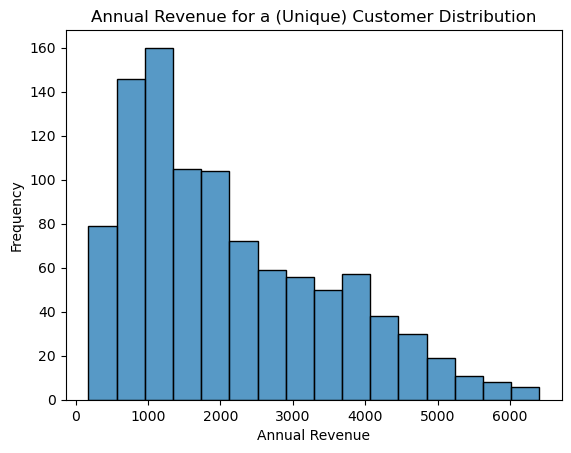


Summary Statistics
count    1000.000000
mean     2126.932487
std      1378.908401
min       176.168871
25%      1029.149805
50%      1775.062706
75%      3086.495046
max      6407.538627
Name: revenue, dtype: float64


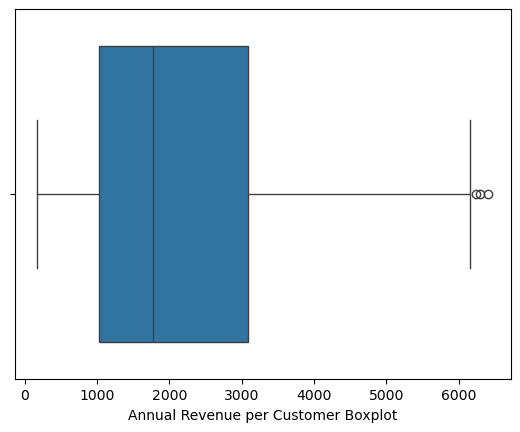

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

revenue_by_true_customer = df.groupby('userid')['revenue'].sum()
true_summary = revenue_by_true_customer.describe()
sns.histplot(revenue_by_true_customer)
plt.xlabel('Annual Revenue')
plt.ylabel('Frequency')
plt.title('Annual Revenue for a (Unique) Customer Distribution')
plt.show()

print()
print("Summary Statistics")
print(revenue_by_true_customer.describe())

sns.boxplot(x=revenue_by_true_customer)
plt.xlabel('Annual Revenue per Customer Boxplot')
plt.show()

## b) The company considers customers who spend more than 3000 per year to be high value customers, those who spend between 1000 and 3000 to be medium value customers, and those who spend below 1000 to be low value customers.

What true fraction of customers fall under each of these three buckets for the company?

In [4]:
revenue_by_true_customer = pd.DataFrame(revenue_by_true_customer)
bins = [0, 1000, 3000, np.inf]
labels = ['Low', 'Medium', 'High']
revenue_by_true_customer['true_bucket'] = pd.cut(revenue_by_true_customer['revenue'], bins=bins, labels=labels)
true_proportion = revenue_by_true_customer['true_bucket'].value_counts(normalize=True)
true_counts = revenue_by_true_customer['true_bucket'].value_counts(normalize=False)
true_proportion


true_bucket
Medium    0.500
High      0.262
Low       0.238
Name: proportion, dtype: float64

# 3. Perform a revenue analysis based on adulterated userIDs, specifically

## a) If the company were to instead use adulterated IDs without identity resolution, what would the revenue distribution look like? Show the distribution of annual revenue based on adulterated userIDs (as a histogram). Also, present the summary statistics of this distribution (mean, standard deviation, 25th percentile, median, and 75th percentile).

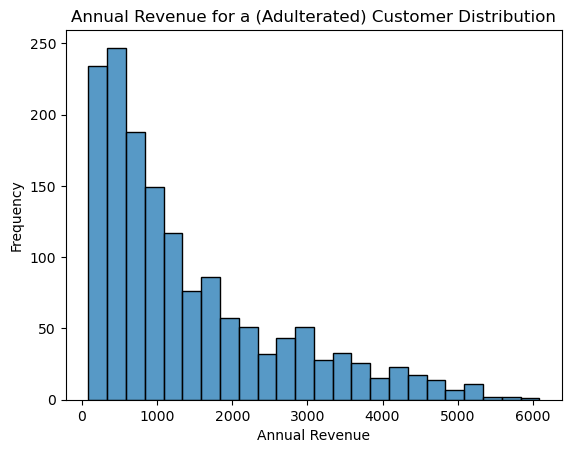


Summary Statistics
count    1510.000000
mean     1408.564561
std      1229.076904
min        85.474101
25%       466.046381
50%       955.836493
75%      1959.501735
max      6087.481182
Name: revenue, dtype: float64


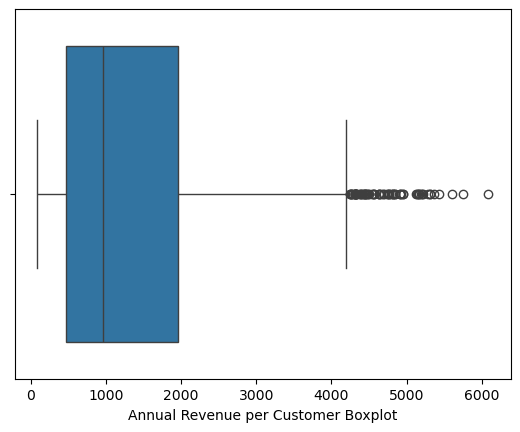

In [5]:
revenue_by_adulterated_customer = df.groupby('id_adulterated')['revenue'].sum()
adulterated_summary = revenue_by_adulterated_customer.describe()
sns.histplot(revenue_by_adulterated_customer)
plt.xlabel('Annual Revenue')
plt.ylabel('Frequency')
plt.title('Annual Revenue for a (Adulterated) Customer Distribution')
plt.show()

print()
print("Summary Statistics")
print(revenue_by_adulterated_customer.describe())

sns.boxplot(x=revenue_by_adulterated_customer)
plt.xlabel('Annual Revenue per Customer Boxplot')
plt.show()

## b) Based on the same definition of high, medium, and low value customers as specified in Question 2(ii), what fraction of customers fall under each of these three buckets?

In [6]:
revenue_by_adulterated_customer = pd.DataFrame(revenue_by_adulterated_customer)
bins = [0, 1000, 3000, np.inf]
labels = ['Low', 'Medium', 'High']
revenue_by_adulterated_customer['adulterated_bucket'] = pd.cut(revenue_by_adulterated_customer['revenue'], bins=bins, labels=labels)
adulterated_proportion = revenue_by_adulterated_customer['adulterated_bucket'].value_counts(normalize=True)
adulterated_counts = revenue_by_adulterated_customer['adulterated_bucket'].value_counts(normalize=False)
adulterated_proportion

adulterated_bucket
Low       0.518543
Medium    0.350993
High      0.130464
Name: proportion, dtype: float64

# 4. What are the main takeaways from comparing the answers to Questions 2 and 3?

In [7]:
proportion_comparison = pd.concat([true_proportion, adulterated_proportion], axis=1)
proportion_comparison.columns = ['true', 'adulterated']
print(proportion_comparison)
print()

counts_comparison = pd.concat([true_counts, adulterated_counts], axis=1)
counts_comparison.columns = ['true', 'adulterated']
print(counts_comparison)
print()

summary_stats_comparison = pd.concat([true_summary, adulterated_summary], axis=1)
summary_stats_comparison.columns = ['True Summary', 'Adulterated Summary']
print(summary_stats_comparison)

         true  adulterated
Medium  0.500     0.350993
High    0.262     0.130464
Low     0.238     0.518543

        true  adulterated
Medium   500          530
High     262          197
Low      238          783

       True Summary  Adulterated Summary
count   1000.000000          1510.000000
mean    2126.932487          1408.564561
std     1378.908401          1229.076904
min      176.168871            85.474101
25%     1029.149805           466.046381
50%     1775.062706           955.836493
75%     3086.495046          1959.501735
max     6407.538627          6087.481182


With true (consolidated) user IDs, the majority of customers are medium value customers at 50%, followed by high and low value  at 26.2% and 23.8% respectively. Without this consolidation using just adulterated id's, the proportion overestimates low value customers to be 51.85% of all the customers. This is because customers that may have bought the 2 brands may be recognized as 2 different customers with lower value transactions when in reality they are one customer and the sum of their transactions pushes them into a higher value bucket. In other words, a single high value cusomer may be classified as multiple lower valued ones.

Using just adultered ids overestimates the customer count at 1510 (vs 1000 true) and underestimates customer value (mean transaction 1408 vs actual 2126).This makes the existing customer base look lower spending then they actually are.

# 5. One of the main marketing initiatives of the company is to encourage medium value consumers to migrate to the next tier, i.e., become high value consumers. To that end, the firm seeks to spend approximately $50 per medium-value customer on direct marketing (emails, push notifications, catalogs and promotions).

Make following assumptions:
- The profit margin is 30% (on the revenues)
- Marketing activities have no incremental impact on the spend of high value customers (they are maxed out)
- On average, the impact of marketing to medium-value customers is an increment of approximately 20% in their yearly spend.

Now calculate:

## a) The ROI of this marketing activity if the firm uses the true userIDs for targeting.

In [ ]:
revenue_by_true_customer["marketing_spend"] = np.where(revenue_by_true_customer["true_bucket"] == "Medium", 50, 0)
print(f"{revenue_by_true_customer['marketing_spend'].sum() / 50} ads sent to {revenue_by_true_customer[revenue_by_true_customer['marketing_spend'] > 0].shape[0]} customers, all in the Medium revenue bucket.")
print(f"Total marketing spend for medium revenue customers: ${revenue_by_true_customer['marketing_spend'].sum():,.2f}")
revenue_by_true_customer["old_profit"] = revenue_by_true_customer["revenue"] * 0.3
revenue_by_true_customer["new_profit"] = np.where(revenue_by_true_customer["true_bucket"] == "Medium", revenue_by_true_customer["old_profit"] * 1.2, revenue_by_true_customer["old_profit"])
print(f"Total profit before marketing spend: ${revenue_by_true_customer['old_profit'].sum():,.2f}")
print(f"Total profit after marketing spend: ${revenue_by_true_customer['new_profit'].sum():,.2f}")
incremental_profit = revenue_by_true_customer['new_profit'].sum() - revenue_by_true_customer['old_profit'].sum()
marketing_spend = revenue_by_true_customer['marketing_spend'].sum()
print(f"Incremental profit from marketing: ${incremental_profit:,.2f}")
print(f"Net gain (incremental profit - marketing spend): ${incremental_profit - marketing_spend:,.2f}")
roi_true = (incremental_profit - marketing_spend) / marketing_spend
print(f"Return on Investment (ROI) for the marketing activity: {roi_true * 100:.2f}%")

## b) The actual ROI realized if the firm instead uses adulterated IDs for targeting.


In [9]:
# Note that in 5(b) you are asked to calculate the actual ROI that would be realized when the firm uses adulterated IDs, 
# whereas in 5(c) you are calculating the ROI as if the adulterated IDs were the true IDs (which is what a naive marketer would do).

mapping = df[['userid' , 'id_adulterated']]
mapping = mapping.drop_duplicates()
mapping.set_index('id_adulterated', inplace=True)
print(f"Mapping of adulterated IDs to true customer IDs:")
print(mapping.head())
print(f"Validating the mapping shape. Expected number of rows should be equal to the number of unique adulterated IDs: {mapping.shape[0]} rows.")
mapping.shape[0] == df['id_adulterated'].nunique()

Mapping of adulterated IDs to true customer IDs:
                userid
id_adulterated        
1                    0
2                    0
3                    1
4                    1
5                    2
Validating the mapping shape. Expected number of rows should be equal to the number of unique adulterated IDs: 1510 rows.


True

In [10]:
# merge the mapping df so we can map to true_ids in next step
revenue_by_adulterated_customer = revenue_by_adulterated_customer.merge(mapping, left_index=True, right_on='id_adulterated', how='left')

# merge revenue_by_adulterated_customer with revenue_by_true_customer to get true_bucket for each adulterated customer. 
revenue_by_adulterated_customer = revenue_by_adulterated_customer.merge(revenue_by_true_customer[['true_bucket']], left_on='userid', right_index=True, how='left')

# a customer is only targetted if their adulterated bucket is medium since thats what is used for targetting
revenue_by_adulterated_customer["targetted"] = np.where(revenue_by_adulterated_customer["adulterated_bucket"] == "Medium", 1, 0)
revenue_by_adulterated_customer.head()

,revenue,adulterated_bucket,userid,true_bucket,targetted
id_adulterated,,,,,
1,195.094274,Low,0,Low,0
2,356.262504,Low,0,Low,0
3,4814.009946,High,1,High,0
4,885.503353,Low,1,High,0
5,3025.526525,High,2,High,0


In [11]:
# bucket makeup of those people tha were targetted
print(revenue_by_adulterated_customer[revenue_by_adulterated_customer["targetted"] == 1]["true_bucket"].value_counts(normalize=False))

# We are wrongly targetting some non-medium bucket users because we are identifying them as medium through their adulterated id. High customesr alreaedy maxed out,
# theres no point in advertising to them.

true_bucket
Medium    428
High      102
Low         0
Name: count, dtype: int64


In [12]:
(revenue_by_adulterated_customer[(revenue_by_adulterated_customer["targetted"] == 0) & (revenue_by_adulterated_customer["true_bucket"] == 'Medium')]).shape
# Likewise, we are also missing out on 328 medium people that we are not targetting because we have misidentified them as low from thier adulterated id
# they become medium through combining their spend across brands, so looking at each individually, they are low

(328, 5)

In [ ]:
# Group by userid, get sum of targetted, sum of revenue, and true_bucket for each true customer. 
x = revenue_by_adulterated_customer.groupby('userid').agg({'targetted': 'sum', 'revenue': 'sum', 'true_bucket': 'first'})
x["marketing_spend"] = x["targetted"] * 50


# a customer is only eligible for a revenue boost if
# 1.they are truly medium value
# 2. they were the target of marketing spend. 
x["old_profit"] = x["revenue"] * 0.3
x["new_profit"] = np.where((x["true_bucket"] == "Medium") & (x["targetted"] > 0), x["old_profit"] * 1.2, x["old_profit"])

# targetted count if the customer was targetted at least once since we are calculating the actual ROI that would be realized when the firm uses adulterated IDs.
print(f"{x['targetted'].sum()} ads sent to {x[x['targetted'] > 0].shape[0]} customers, some of which are not in the Medium revenue bucket due to misidentification from adulterated IDs.")
print(f"Total Marketing Spend: ${x['marketing_spend'].sum():,.2f}")
print(f"Total profit before marketing spend: ${x['old_profit'].sum():,.2f}")
print(f"Total profit after marketing spend: ${x['new_profit'].sum():,.2f}")
incremental_profit = x['new_profit'].sum() - x['old_profit'].sum()
marketing_spend = x['marketing_spend'].sum()
print(f"Incremental profit from marketing: ${incremental_profit:,.2f}")
print(f"Net gain (incremental profit - marketing spend): ${incremental_profit - marketing_spend:,.2f}")
roi_actual = (incremental_profit - marketing_spend) / marketing_spend
print(f"Return on Investment (ROI) for the marketing activity: {roi_actual * 100:.2f}%")

## c) Finally, what would a marketer who naively uses the adulterated IDs (yet treating them as true IDs) expect the ROI to be?

In [ ]:
# Note that in 5(b) you are asked to calculate the actual ROI that would be realized when the firm uses adulterated IDs, 
# whereas in 5(c) you are calculating the ROI as if the adulterated IDs were the true IDs (which is what a naive marketer would do).
revenue_by_adulterated_customer["marketing_spend"] = np.where(revenue_by_adulterated_customer["adulterated_bucket"] == "Medium", 50, 0)
print(f"Total marketing spend for medium revenue customers: ${revenue_by_adulterated_customer['marketing_spend'].sum():,.2f}")
revenue_by_adulterated_customer["old_profit"] = revenue_by_adulterated_customer["revenue"] * 0.3
revenue_by_adulterated_customer["new_profit"] = np.where(revenue_by_adulterated_customer["adulterated_bucket"] == "Medium", revenue_by_adulterated_customer["old_profit"] * 1.2, revenue_by_adulterated_customer["old_profit"])
print(f"Total profit before marketing spend: ${revenue_by_adulterated_customer['old_profit'].sum():,.2f}")
print(f"Total profit after marketing spend: ${revenue_by_adulterated_customer['new_profit'].sum():,.2f}")
incremental_profit = revenue_by_adulterated_customer['new_profit'].sum() - revenue_by_adulterated_customer['old_profit'].sum()
marketing_spend = revenue_by_adulterated_customer['marketing_spend'].sum()
print(f"Incremental profit from marketing: ${incremental_profit:,.2f}")
print(f"Net gain (incremental profit - marketing spend): ${incremental_profit - marketing_spend:,.2f}")
roi_adulterated = (incremental_profit - marketing_spend) / marketing_spend
print(f"Return on Investment (ROI) for the marketing activity: {roi_adulterated * 100:.2f}%")

## d) Compare the ROIs from your answers to Questions 5(a), 5(b), and 5(c). What is the reason for the discrepancy, and what are the main takeaways?

Using the true customer IDs for targeting yields an ROI of 214.91%, while the actual ROI realized when the firm targets using adulterated IDs is only 181.38%. A naive marketer who evaluates performance treating adulterated IDs as true customers would estimate the ROI to be 215.25%, which is very close to the true-ID ROI. However, this similarity is misleading. The naive calculation measures both targeting and performance within the same fragmented ID system, so the errors in customer identification affect the numerator (incremental profit) and denominator (number of targeted “customers”) in offsetting ways, producing an ROI that appears accurate even though it is not based on real customers.

The true test is the realized ROI in (b). In reality, the firm sends 530 marketing messages to what are actually 500 customers, incurring higher costs while only 423 true medium-value customers generate incremental spend. This results in wasted marketing spend and missed opportunities to upgrade all eligible medium customers, which lowers the actual ROI to 181.38%. Therefore, the advantage of using unified customer IDs is not only a higher realized return, but also accurate measurement, correct customer counts, proper tier migration, and more efficient budget allocation. The naive approach in (c) is dangerous because it creates a false sense of performance and can lead the firm to overinvest in campaigns based on overstated effectiveness.